# SHD FF v3 neuron comparison

This notebook scans `result/v3/<neuron>/` and compares neurons (e.g., `lif`, `alif`, `srm`, `dynsrm`) on:

- final / best accuracy and macro-F1
- convergence curves
- latency and throughput
- event-driven efficiency proxies
- per-layer spike rate

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='talk')

BASE_DIR = Path('/home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/FF/SHD/result/v3')
csv_files = sorted(BASE_DIR.glob('*/*.csv'))

if not csv_files:
    raise FileNotFoundError(f'No CSV found under {BASE_DIR}/*/*.csv')

print(f'Found {len(csv_files)} CSV files')
for p in csv_files[:8]:
    print(' -', p)
if len(csv_files) > 8:
    print(' ...')

Found 30 CSV files
 - /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/FF/SHD/result/v3/alif/SHD_alif_FF_v3_20260503_235634.csv
 - /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/FF/SHD/result/v3/alif/SHD_alif_FF_v3_20260503_235634_best_eval_confusion.csv
 - /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/FF/SHD/result/v3/alif/SHD_alif_FF_v3_20260503_235634_final_eval_confusion.csv
 - /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/FF/SHD/result/v3/alif/SHD_alif_FF_v3_20260504_001352.csv
 - /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/FF/SHD/result/v3/alif/SHD_alif_FF_v3_20260504_001352_best_eval_confusion.csv
 - /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/FF/SHD/result/v3/alif/SHD_alif_FF_v3_20260504_001352_final_eval_confusion.csv
 - /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/FF/SHD/result/v3/dynsrm/SHD_dynsrm_FF_v3_20260503_161458.csv
 - /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/FF/SHD/result/v3/dynsrm/

In [2]:
def load_runs(csv_paths):
    frames = []
    for p in csv_paths:
        try:
            df = pd.read_csv(p)
        except Exception as e:
            print(f'[skip] failed to read {p}: {e}')
            continue
        if df.empty:
            continue
        df = df.copy()
        df['csv_path'] = str(p)
        df['neuron_dir'] = p.parent.name
        if 'model' not in df.columns:
            df['model'] = df['neuron_dir']
        frames.append(df)
    if not frames:
        raise RuntimeError('No valid result tables were loaded.')
    return pd.concat(frames, ignore_index=True)

all_df = load_runs(csv_files)
all_df['epoch'] = pd.to_numeric(all_df['epoch'], errors='coerce')
all_df['test_acc'] = pd.to_numeric(all_df.get('test_acc', np.nan), errors='coerce')
all_df['test_macro_f1'] = pd.to_numeric(all_df.get('test_macro_f1', np.nan), errors='coerce')

# A run is identified by (model, run_id, csv_path). Keep each run's max-epoch row as final epoch.
group_keys = ['model', 'run_id', 'csv_path']
final_idx = all_df.groupby(group_keys)['epoch'].idxmax()
final_df = all_df.loc[final_idx].reset_index(drop=True)

# Best epoch per run by test_acc
best_idx = all_df.groupby(group_keys)['test_acc'].idxmax()
best_df = all_df.loc[best_idx].reset_index(drop=True)

print('All rows:', len(all_df))
print('Final rows (one per run):', len(final_df))
display(final_df[['model', 'run_id', 'epoch', 'test_acc', 'test_macro_f1', 'test_latency_ms_per_sample', 'test_event_to_dense_ratio']].sort_values(['model', 'run_id']).head(20))

All rows: 4010
Final rows (one per run): 10


,model,run_id,epoch,test_acc,test_macro_f1,test_latency_ms_per_sample,test_event_to_dense_ratio
0,alif,20260503_235634,5.0,0.496324,0.497599,6.839493,0.338489
1,alif,20260504_001352,500.0,0.672794,0.675322,8.304717,0.330696
2,dynsrm,20260503_161458,500.0,0.800245,0.797760,1.784099,0.293427
3,dynsrm,20260503_201837,500.0,0.792892,0.790427,1.307011,0.292112
4,dynsrm,20260503_201938,300.0,0.806373,0.803568,1.206881,0.294013
5,lif,20260503_150517,300.0,0.648284,0.650948,0.541508,0.332208
6,lif,20260503_153945,500.0,0.666667,0.668846,0.573165,0.331642
7,lif,20260503_235746,5.0,0.448529,0.426496,5.774768,0.282769
8,lif,20260504_001337,500.0,0.633578,0.631508,8.561209,0.286264
9,srm,20260503_235551,500.0,0.790441,0.790388,8.770423,0.288383


In [3]:
def aggregate_model_stats(df, tag):
    metrics = [
        'test_acc',
        'test_macro_f1',
        'test_latency_ms_per_sample',
        'test_speed',
        'test_event_to_dense_ratio',
        'test_event_synops',
        'test_global_spike_rate',
    ]
    use_cols = ['model'] + [m for m in metrics if m in df.columns]
    out = df[use_cols].groupby('model').agg(['mean', 'std', 'count'])
    out.columns = [f'{c[0]}_{c[1]}' for c in out.columns]
    out = out.reset_index().sort_values('model').reset_index(drop=True)
    print(f'\\n[{tag}] model-level statistics')
    display(out)
    return out

final_stats = aggregate_model_stats(final_df, 'final epoch')
best_stats = aggregate_model_stats(best_df, 'best epoch by test_acc')

\n[final epoch] model-level statistics


,model,test_acc_mean,test_acc_std,test_acc_count,test_macro_f1_mean,test_macro_f1_std,test_macro_f1_count,test_latency_ms_per_sample_mean,test_latency_ms_per_sample_std,test_latency_ms_per_sample_count,...,test_speed_count,test_event_to_dense_ratio_mean,test_event_to_dense_ratio_std,test_event_to_dense_ratio_count,test_event_synops_mean,test_event_synops_std,test_event_synops_count,test_global_spike_rate_mean,test_global_spike_rate_std,test_global_spike_rate_count
0,alif,0.584559,0.124784,2,0.586460,0.125669,2,7.572105,1.036070,2,...,2,0.334593,0.005510,2,3.330940e+10,5.485812e+08,2,0.203650,0.006723,2
1,dynsrm,0.799837,0.006749,3,0.797252,0.006585,3,1.432663,0.308442,3,...,3,0.293184,0.000974,3,2.346407e+10,1.000503e+10,3,0.156262,0.004304,3
2,lif,0.599265,0.101398,4,0.594450,0.113002,4,3.862663,3.982602,4,...,4,0.308220,0.027409,4,3.068397e+10,2.728662e+09,4,0.171476,0.033439,4
3,srm,0.790441,NaN,1,0.790388,NaN,1,8.770423,NaN,1,...,1,0.288383,NaN,1,2.870907e+10,NaN,1,0.147274,NaN,1


\n[best epoch by test_acc] model-level statistics


,model,test_acc_mean,test_acc_std,test_acc_count,test_macro_f1_mean,test_macro_f1_std,test_macro_f1_count,test_latency_ms_per_sample_mean,test_latency_ms_per_sample_std,test_latency_ms_per_sample_count,...,test_speed_count,test_event_to_dense_ratio_mean,test_event_to_dense_ratio_std,test_event_to_dense_ratio_count,test_event_synops_mean,test_event_synops_std,test_event_synops_count,test_global_spike_rate_mean,test_global_spike_rate_std,test_global_spike_rate_count
0,alif,0.584559,0.124784,2,0.586460,0.125669,2,7.572105,1.036070,2,...,2,0.334593,0.005510,2,3.330940e+10,5.485812e+08,2,0.203650,0.006723,2
1,dynsrm,0.810866,0.003939,3,0.808569,0.004315,3,1.403208,0.397666,3,...,3,0.293462,0.001136,3,2.349022e+10,1.002491e+10,3,0.156613,0.004112,3
2,lif,0.607843,0.106667,4,0.603161,0.118490,4,3.929174,4.123028,4,...,4,0.309145,0.026826,4,3.077596e+10,2.670547e+09,4,0.172603,0.032727,4
3,srm,0.802696,NaN,1,0.800928,NaN,1,8.584051,NaN,1,...,1,0.289101,NaN,1,2.878054e+10,NaN,1,0.148149,NaN,1


/tmp/ipykernel_561963/4173337145.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='model', y=m, order=models, errorbar=('sd', 1), ax=ax, palette='tab10')
/tmp/ipykernel_561963/4173337145.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='model', y=m, order=models, errorbar=('sd', 1), ax=ax, palette='tab10')
/tmp/ipykernel_561963/4173337145.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='model', y=m, order=models, errorbar=('sd', 1), ax=ax, palette='tab10')
/tmp/ipykernel_561963/4173337145.py:11: 

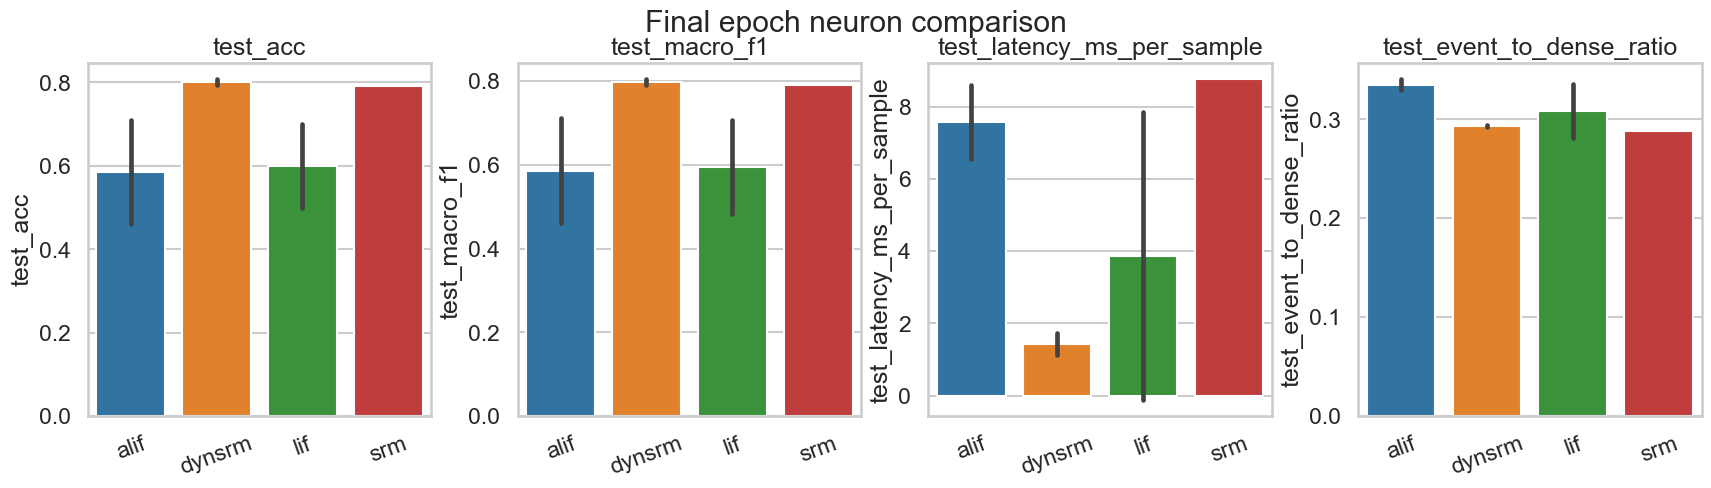

/tmp/ipykernel_561963/4173337145.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='model', y=m, order=models, errorbar=('sd', 1), ax=ax, palette='tab10')
/tmp/ipykernel_561963/4173337145.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='model', y=m, order=models, errorbar=('sd', 1), ax=ax, palette='tab10')
/tmp/ipykernel_561963/4173337145.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='model', y=m, order=models, errorbar=('sd', 1), ax=ax, palette='tab10')
/tmp/ipykernel_561963/4173337145.py:11: 

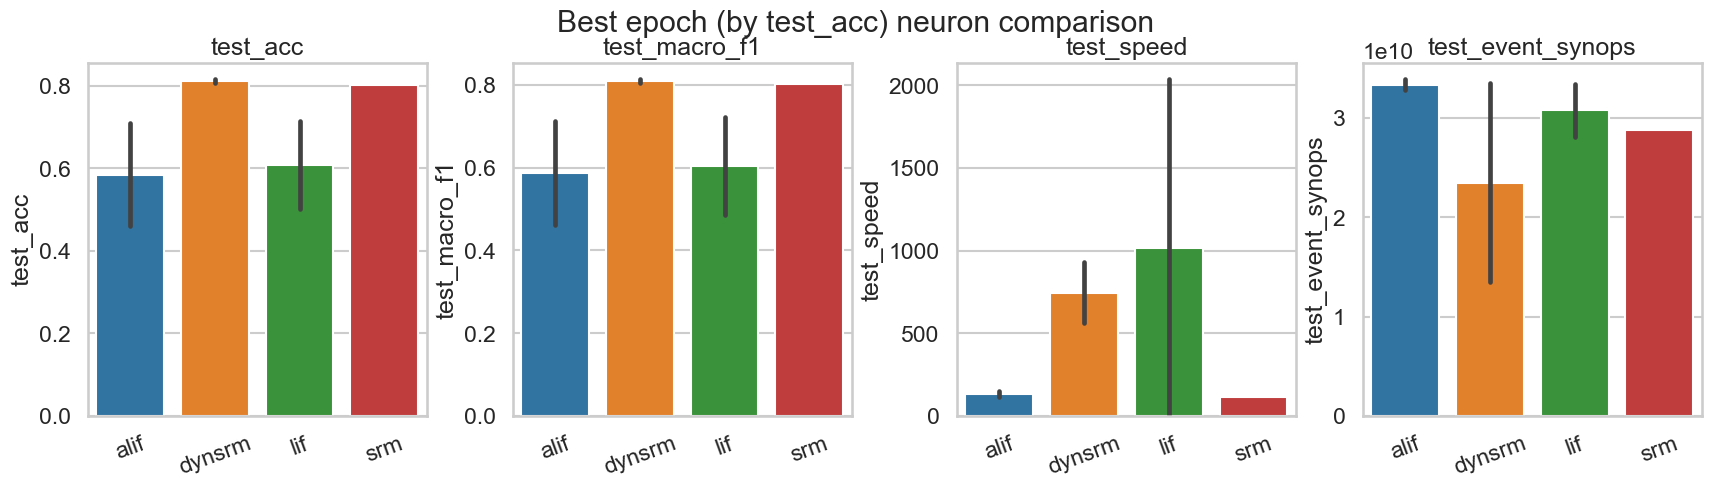

In [4]:
def bar_compare(df, metrics, title_prefix='', figsize=(17, 4.5)):
    models = sorted(df['model'].dropna().unique().tolist())
    n = len(metrics)
    fig, axes = plt.subplots(1, n, figsize=figsize, constrained_layout=True)
    if n == 1:
        axes = [axes]
    for ax, m in zip(axes, metrics):
        if m not in df.columns:
            ax.set_visible(False)
            continue
        sns.barplot(data=df, x='model', y=m, order=models, errorbar=('sd', 1), ax=ax, palette='tab10')
        ax.set_title(m)
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=20)
    fig.suptitle(f'{title_prefix} neuron comparison', y=1.05)
    plt.show()

bar_compare(
    final_df,
    metrics=['test_acc', 'test_macro_f1', 'test_latency_ms_per_sample', 'test_event_to_dense_ratio'],
    title_prefix='Final epoch',
)

bar_compare(
    best_df,
    metrics=['test_acc', 'test_macro_f1', 'test_speed', 'test_event_synops'],
    title_prefix='Best epoch (by test_acc)',
)


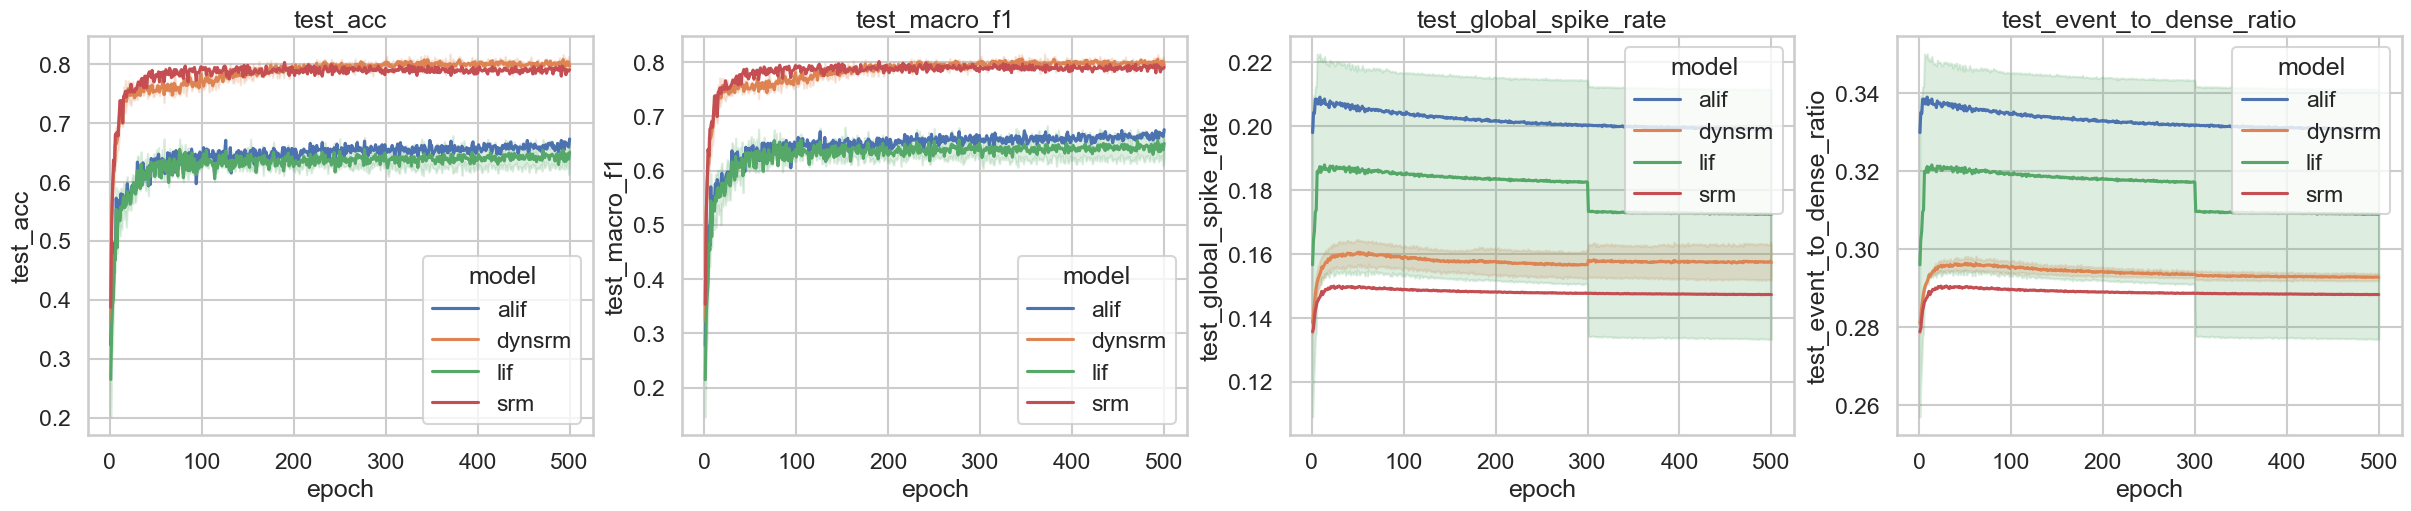

In [5]:
# Convergence curves: mean +/- std across runs for each neuron
plot_df = all_df.copy()
plot_df = plot_df.dropna(subset=['epoch'])

curve_metrics = [m for m in ['test_acc', 'test_macro_f1', 'test_global_spike_rate', 'test_event_to_dense_ratio'] if m in plot_df.columns]
if not curve_metrics:
    raise RuntimeError('No curve metrics found in CSV.')

fig, axes = plt.subplots(1, len(curve_metrics), figsize=(6 * len(curve_metrics), 5), constrained_layout=True)
if len(curve_metrics) == 1:
    axes = [axes]

for ax, metric in zip(axes, curve_metrics):
    sns.lineplot(data=plot_df, x='epoch', y=metric, hue='model', estimator='mean', errorbar='sd', ax=ax)
    ax.set_title(metric)
    ax.legend(title='model')
plt.show()

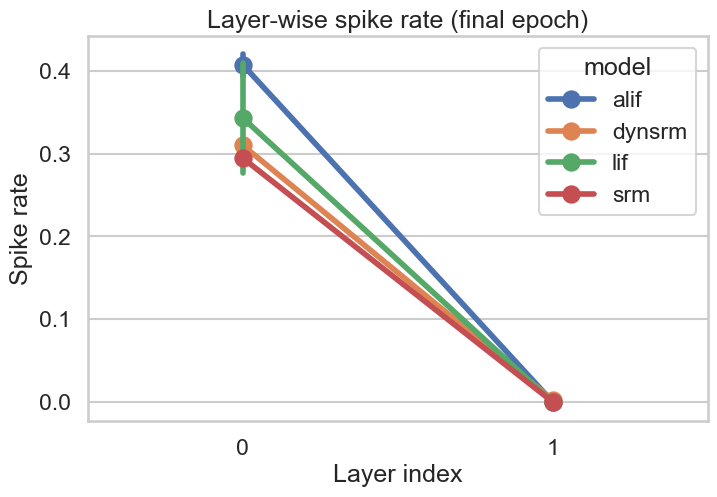

In [8]:
# Layer-wise spike-rate comparison (final epoch)
layer_rate_cols = [c for c in final_df.columns if c.startswith('test_layer_') and c.endswith('_spike_rate')]
if not layer_rate_cols:
    print('No layer spike-rate columns found.')
else:
    long_df = final_df[['model'] + layer_rate_cols].melt(id_vars='model', var_name='layer', value_name='spike_rate')
    long_df['layer'] = long_df['layer'].str.extract(r'test_layer_(\d+)_spike_rate', expand=False)
    long_df['layer'] = pd.to_numeric(long_df['layer'], errors='coerce')
    long_df = long_df.dropna(subset=['layer'])
    long_df['layer'] = long_df['layer'].astype(int)

    plt.figure(figsize=(8, 5))
    sns.pointplot(data=long_df, x='layer', y='spike_rate', hue='model', errorbar=('sd', 1))
    plt.title('Layer-wise spike rate (final epoch)')
    plt.xlabel('Layer index')
    plt.ylabel('Spike rate')
    plt.show()

,model,run_id,test_acc,test_latency_ms_per_sample,test_event_to_dense_ratio,efficiency_score
5,lif,20260503_150517,0.648284,0.541508,0.332208,3.603718
6,lif,20260503_153945,0.666667,0.573165,0.331642,3.507195
4,dynsrm,20260503_201938,0.806373,1.206881,0.294013,2.272502
3,dynsrm,20260503_201837,0.792892,1.307011,0.292112,2.076756
2,dynsrm,20260503_161458,0.800245,1.784099,0.293427,1.528635
9,srm,20260503_235551,0.790441,8.770423,0.288383,0.312521
7,lif,20260503_235746,0.448529,5.774768,0.282769,0.274679
8,lif,20260504_001337,0.633578,8.561209,0.286264,0.258523
1,alif,20260504_001352,0.672794,8.304717,0.330696,0.244978
0,alif,20260503_235634,0.496324,6.839493,0.338489,0.214386


/tmp/ipykernel_561963/568518066.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=eff_df, x='model', y='efficiency_score', errorbar=('sd', 1), palette='Set2')


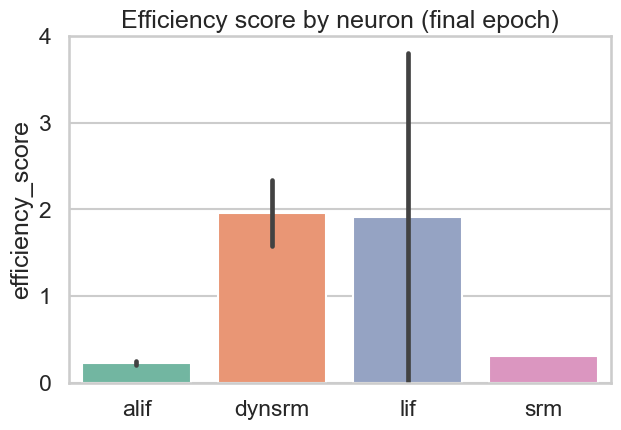

In [9]:
# Optional: derive an efficiency score (higher is better)
# score = test_acc / (latency * event_ratio)
eff_df = final_df.copy()
need_cols = ['test_acc', 'test_latency_ms_per_sample', 'test_event_to_dense_ratio']
if all(c in eff_df.columns for c in need_cols):
    eps = 1e-12
    eff_df['efficiency_score'] = eff_df['test_acc'] / (
        (eff_df['test_latency_ms_per_sample'] + eps) * (eff_df['test_event_to_dense_ratio'] + eps)
    )
    display(
        eff_df[['model', 'run_id', 'test_acc', 'test_latency_ms_per_sample', 'test_event_to_dense_ratio', 'efficiency_score']]
        .sort_values('efficiency_score', ascending=False)
        .head(20)
    )
    plt.figure(figsize=(7, 4.5))
    sns.barplot(data=eff_df, x='model', y='efficiency_score', errorbar=('sd', 1), palette='Set2')
    plt.title('Efficiency score by neuron (final epoch)')
    plt.xlabel('')
    plt.show()
else:
    print('Missing columns for efficiency score:', [c for c in need_cols if c not in eff_df.columns])

DynSRM rows: 1300 | runs(final): 3 | runs(best): 3
hidden_dim values found: [32, 256, 500]

[Final epoch] hidden_dim comparison


/tmp/ipykernel_561963/3729714505.py:14: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ~dyn_df['csv_path'].astype(str).str.contains(r'(best_eval_confusion|final_eval_confusion)\.csv$', regex=True, na=False)


,hidden_dim_cmp,test_acc_mean,test_acc_std,test_acc_count,test_macro_f1_mean,test_macro_f1_std,test_macro_f1_count,test_latency_ms_per_sample_mean,test_latency_ms_per_sample_std,test_latency_ms_per_sample_count,...,test_speed_count,test_event_to_dense_ratio_mean,test_event_to_dense_ratio_std,test_event_to_dense_ratio_count,test_event_synops_mean,test_event_synops_std,test_event_synops_count,test_global_spike_rate_mean,test_global_spike_rate_std,test_global_spike_rate_count
0,32,0.806373,NaN,1,0.803568,NaN,1,1.206881,NaN,1,...,1,0.294013,NaN,1,2.926963e+10,NaN,1,0.154143,NaN,1
1,256,0.792892,NaN,1,0.790427,NaN,1,1.307011,NaN,1,...,1,0.292112,NaN,1,1.191131e+10,NaN,1,0.161215,NaN,1
2,500,0.800245,NaN,1,0.797760,NaN,1,1.784099,NaN,1,...,1,0.293427,NaN,1,2.921127e+10,NaN,1,0.153428,NaN,1



[Best epoch by test_acc] hidden_dim comparison


,hidden_dim_cmp,test_acc_mean,test_acc_std,test_acc_count,test_macro_f1_mean,test_macro_f1_std,test_macro_f1_count,test_latency_ms_per_sample_mean,test_latency_ms_per_sample_std,test_latency_ms_per_sample_count,...,test_speed_count,test_event_to_dense_ratio_mean,test_event_to_dense_ratio_std,test_event_to_dense_ratio_count,test_event_synops_mean,test_event_synops_std,test_event_synops_count,test_global_spike_rate_mean,test_global_spike_rate_std,test_global_spike_rate_count
0,32,0.806373,NaN,1,0.803618,NaN,1,1.122948,NaN,1,...,1,0.294375,NaN,1,2.930563e+10,NaN,1,0.154584,NaN,1
1,256,0.813725,NaN,1,0.811531,NaN,1,1.228332,NaN,1,...,1,0.292190,NaN,1,1.191449e+10,NaN,1,0.161345,NaN,1
2,500,0.812500,NaN,1,0.810558,NaN,1,1.858344,NaN,1,...,1,0.293822,NaN,1,2.925053e+10,NaN,1,0.153909,NaN,1


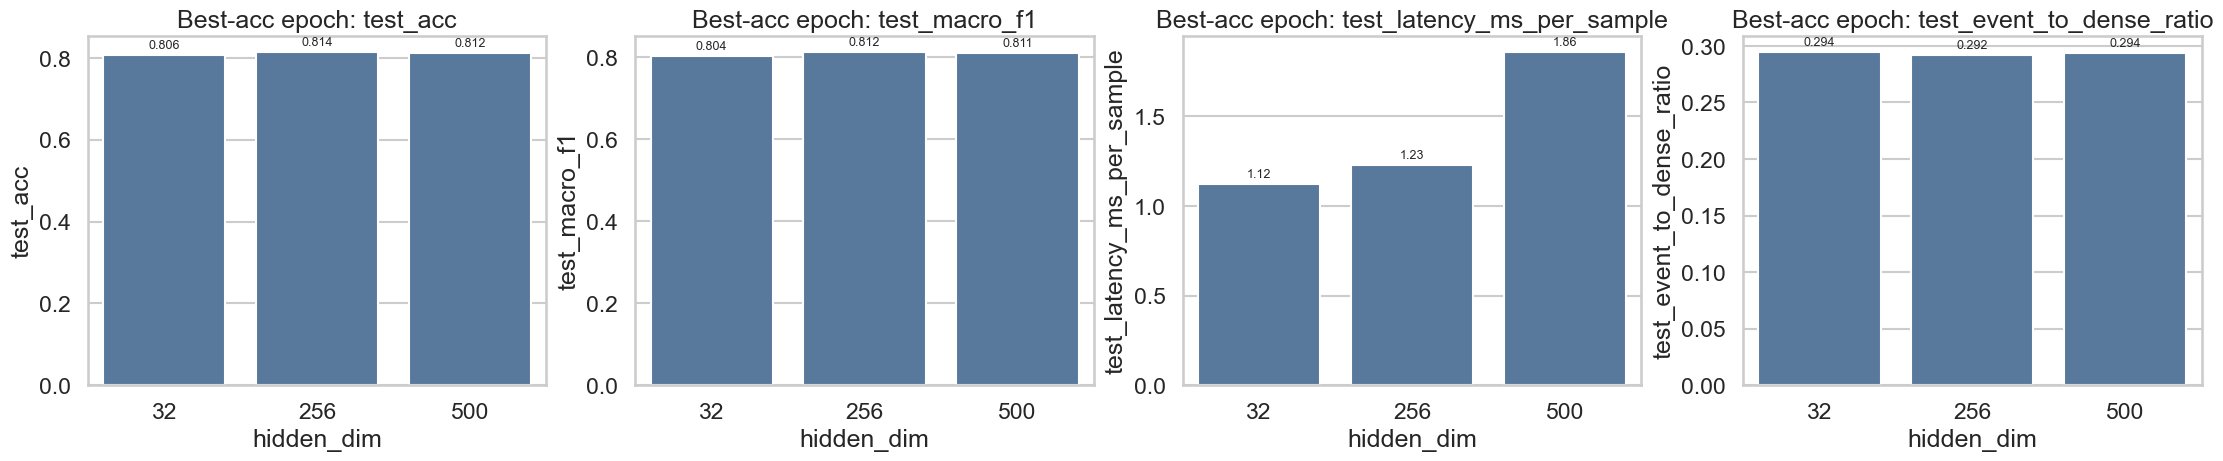

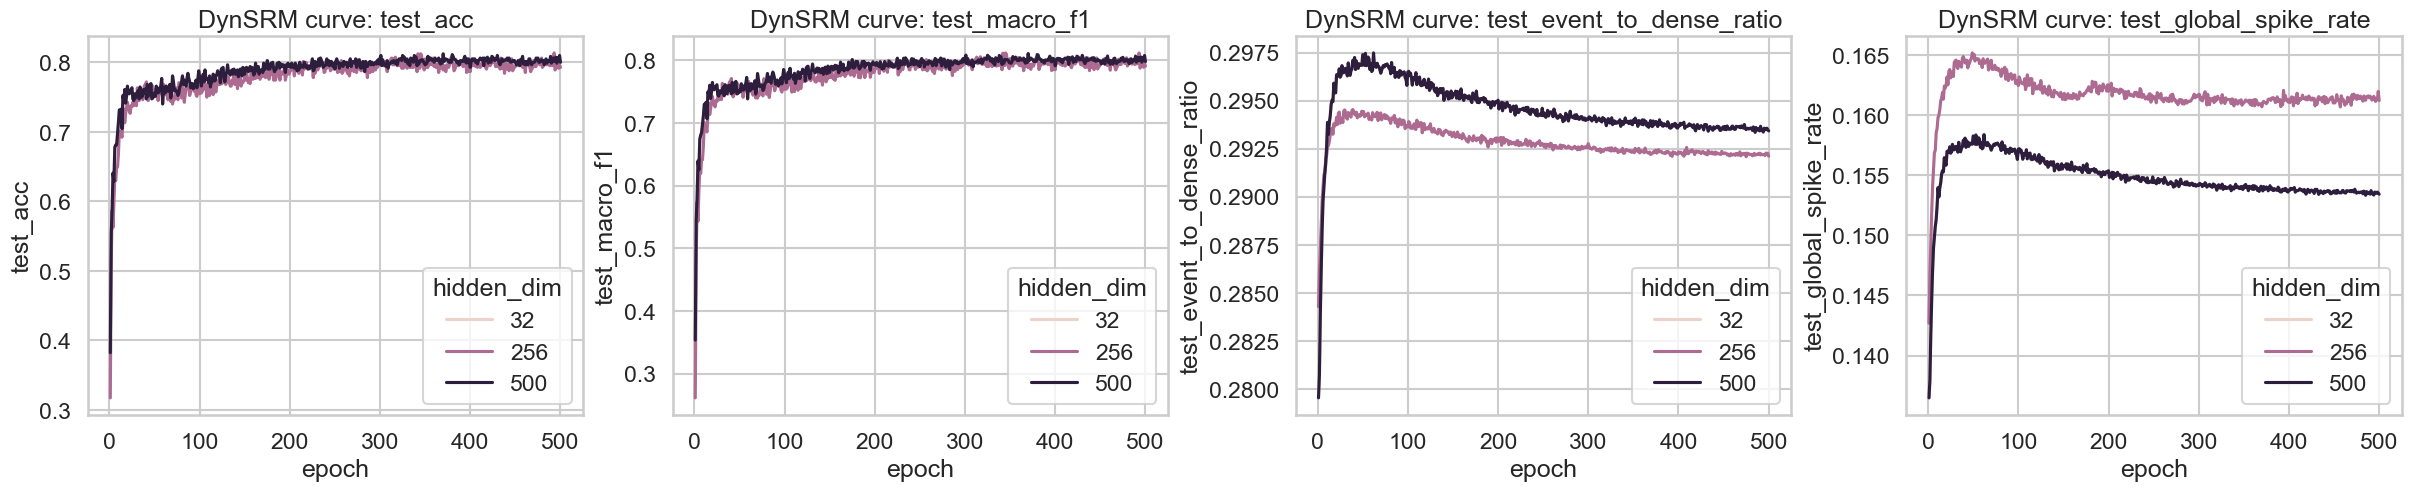

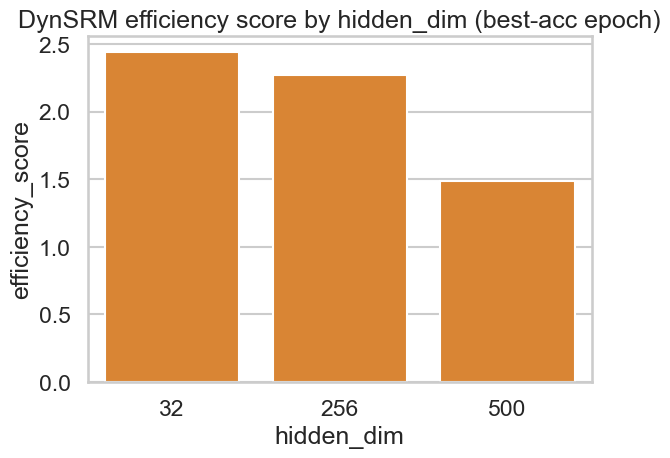

In [13]:
# DynSRM: compare different hidden_dim settings (e.g., dynsrm_32 vs default 500)
import re

# Filter DynSRM-related runs: match by model / folder name / csv path
mask_dynsrm = (
    all_df.get('model', '').astype(str).str.lower().str.contains('dynsrm', na=False)
    | all_df.get('neuron_dir', '').astype(str).str.lower().str.contains('dynsrm', na=False)
    | all_df.get('csv_path', '').astype(str).str.lower().str.contains(r'/dynsrm', na=False)
)
dyn_df = all_df.loc[mask_dynsrm].copy()

# Keep only training-metrics CSV rows (exclude confusion matrix CSVs)
dyn_df = dyn_df.loc[
    ~dyn_df['csv_path'].astype(str).str.contains(r'(best_eval_confusion|final_eval_confusion)\.csv$', regex=True, na=False)
].copy()

if dyn_df.empty:
    print('No DynSRM runs found under result/v3.')
else:
    # Prefer hidden_dim parsed from folder name, e.g., dynsrm_32 -> 32
    # This guarantees dynsrm_32 is included even if CSV hidden_dim is missing/inconsistent.
    dir_hidden = dyn_df['neuron_dir'].astype(str).str.extract(r'dynsrm_(\d+)', expand=False)
    dir_hidden = pd.to_numeric(dir_hidden, errors='coerce')

    csv_hidden = pd.to_numeric(dyn_df.get('hidden_dim', np.nan), errors='coerce')
    dyn_df['hidden_dim_cmp'] = csv_hidden
    dyn_df.loc[dir_hidden.notna(), 'hidden_dim_cmp'] = dir_hidden[dir_hidden.notna()]

    dyn_df = dyn_df.dropna(subset=['hidden_dim_cmp'])
    dyn_df['hidden_dim_cmp'] = dyn_df['hidden_dim_cmp'].astype(int)

    # One row per run at final epoch
    dyn_group_keys = ['run_id', 'csv_path']
    dyn_final_idx = dyn_df.groupby(dyn_group_keys)['epoch'].idxmax()
    dyn_final = dyn_df.loc[dyn_final_idx].copy()

    # One row per run at best test_acc epoch
    dyn_best_idx = dyn_df.groupby(dyn_group_keys)['test_acc'].idxmax()
    dyn_best = dyn_df.loc[dyn_best_idx].copy()

    print(f'DynSRM rows: {len(dyn_df)} | runs(final): {len(dyn_final)} | runs(best): {len(dyn_best)}')
    print('hidden_dim values found:', sorted(dyn_df['hidden_dim_cmp'].unique().tolist()))

    # Table: hidden_dim-level statistics
    compare_metrics = [
        'test_acc',
        'test_macro_f1',
        'test_latency_ms_per_sample',
        'test_speed',
        'test_event_to_dense_ratio',
        'test_event_synops',
        'test_global_spike_rate',
    ]
    use_cols = ['hidden_dim_cmp'] + [m for m in compare_metrics if m in dyn_final.columns]

    final_stats = dyn_final[use_cols].groupby('hidden_dim_cmp').agg(['mean', 'std', 'count'])
    final_stats.columns = [f'{a}_{b}' for a, b in final_stats.columns]
    final_stats = final_stats.reset_index().sort_values('hidden_dim_cmp')

    best_stats = dyn_best[use_cols].groupby('hidden_dim_cmp').agg(['mean', 'std', 'count'])
    best_stats.columns = [f'{a}_{b}' for a, b in best_stats.columns]
    best_stats = best_stats.reset_index().sort_values('hidden_dim_cmp')

    print('\n[Final epoch] hidden_dim comparison')
    display(final_stats)
    print('\n[Best epoch by test_acc] hidden_dim comparison')
    display(best_stats)

    # Bar plots for key metrics (using best epoch by test_acc)
    plot_metrics = [m for m in ['test_acc', 'test_macro_f1', 'test_latency_ms_per_sample', 'test_event_to_dense_ratio'] if m in dyn_best.columns]
    if plot_metrics:
        fig, axes = plt.subplots(1, len(plot_metrics), figsize=(5.5 * len(plot_metrics), 4.5), constrained_layout=True)
        if len(plot_metrics) == 1:
            axes = [axes]

        for ax, m in zip(axes, plot_metrics):
            sns.barplot(data=dyn_best, x='hidden_dim_cmp', y=m, errorbar=('sd', 1), ax=ax, color='#4C78A8')
            ax.set_title(f'Best-acc epoch: {m}')
            ax.set_xlabel('hidden_dim')

            # Annotate each bar with value (accuracy/F1 as 3 decimals, others as compact float)
            y_max = ax.get_ylim()[1]
            for p in ax.patches:
                h = p.get_height()
                if np.isnan(h):
                    continue
                if m in ['test_acc', 'test_macro_f1']:
                    txt = f'{h:.3f}'
                else:
                    txt = f'{h:.3g}'
                ax.text(
                    p.get_x() + p.get_width() / 2.0,
                    h + 0.01 * y_max,
                    txt,
                    ha='center',
                    va='bottom',
                    fontsize=9,
                    rotation=0,
                )

        plt.show()

    # Convergence curves by hidden_dim
    curve_metrics = [m for m in ['test_acc', 'test_macro_f1', 'test_event_to_dense_ratio', 'test_global_spike_rate'] if m in dyn_df.columns]
    if curve_metrics:
        fig, axes = plt.subplots(1, len(curve_metrics), figsize=(6 * len(curve_metrics), 4.8), constrained_layout=True)
        if len(curve_metrics) == 1:
            axes = [axes]
        for ax, m in zip(axes, curve_metrics):
            sns.lineplot(data=dyn_df, x='epoch', y=m, hue='hidden_dim_cmp', estimator='mean', errorbar='sd', ax=ax)
            ax.set_title(f'DynSRM curve: {m}')
            ax.legend(title='hidden_dim')
        plt.show()

    # Optional efficiency score for DynSRM hidden_dim comparison (using best-acc epoch)
    need = ['test_acc', 'test_latency_ms_per_sample', 'test_event_to_dense_ratio']
    if all(c in dyn_best.columns for c in need):
        eps = 1e-12
        dyn_best = dyn_best.copy()
        dyn_best['efficiency_score'] = dyn_best['test_acc'] / (
            (dyn_best['test_latency_ms_per_sample'] + eps) * (dyn_best['test_event_to_dense_ratio'] + eps)
        )
        plt.figure(figsize=(6.5, 4.5))
        sns.barplot(data=dyn_best, x='hidden_dim_cmp', y='efficiency_score', errorbar=('sd', 1), color='#F58518')
        plt.title('DynSRM efficiency score by hidden_dim (best-acc epoch)')
        plt.xlabel('hidden_dim')
        plt.show()
